# Banknote dimensions

Which banknotes exhibit the greatest size differences between denominations? Which are the largest overall?

Banknote dimensions differ widely across countries.

The size of a banknote impacts its practicality. Uniform dimensions enhance durability by ensuring a snug wallet fit, while also enabling vending machines and ATMs to process them seamlessly. Conversely, varied sizes assist the visually impaired in distinguishing denominations, though smaller notes can pose challenges for machine sorting and counting.

Striking a balance between these considerations is essential in currency design.

The file `banknote-dimensions.csv` shows the `length` and `width` in millimeters for 42 currencies. This dataset spans all 22 subregions and sub-subregions of the world, as defined by the United Nations Statistics Division's geoscheme.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("C:\\Users\\miaos\\Desktop\\Datasets\\banknote-dimensions-project\\banknote-dimensions.csv")
df

,currency,code,value,length,width
0,Argentine Peso,ARS,2,155.0,65.0
1,Argentine Peso,ARS,5,155.0,65.0
2,Argentine Peso,ARS,10,155.0,65.0
3,Argentine Peso,ARS,20,155.0,65.0
4,Argentine Peso,ARS,50,155.0,65.0
...,...,...,...,...,...
245,West African Franc,XOF,500,114.0,60.0
246,West African Franc,XOF,1000,125.0,66.0
247,West African Franc,XOF,2000,130.0,65.0
248,West African Franc,XOF,5000,140.0,74.0


In [2]:
# longest and shortest banknotes for each currency
# modify the code below if you are more interested in width
length = df.groupby('currency').agg(max=('length', 'max'), min=('length', 'min')).reset_index()
length['diff'] = length['max'] - length['min']
length.head()

,currency,max,min,diff
0,Argentine Peso,155.0,155.0,0.0
1,Australian Dollar,158.0,130.0,28.0
2,Bangladeshi Taka,155.0,100.0,55.0
3,Bolivian Boliviano,140.0,140.0,0.0
4,Canadian Dollar,152.4,152.4,0.0


In [3]:
# helper function, change gap, vertical alignment, horizontal alignment, placement of gap...
def add_labels(df, x_col, y_col, label_col):
	for i, row in df.iterrows():
		x = row[x_col]
		y = row[y_col]
		gap = "  "
		label = gap + row[label_col]
		plt.text(x, y, label, va='center', ha='left')

### Project Ideas

- Generate paired scatter plots to compare the `length` of the longest and shortest banknotes for each currency.

- Create similar paired scatter plots, but for `width` instead of `length`.

- Incorporate the Pro Tips into your visualizations.

- Add labels to data points to highlight key insights or narrate a compelling story.

Below is a preliminary paired scatter plot of banknote length to serve as a starting point.

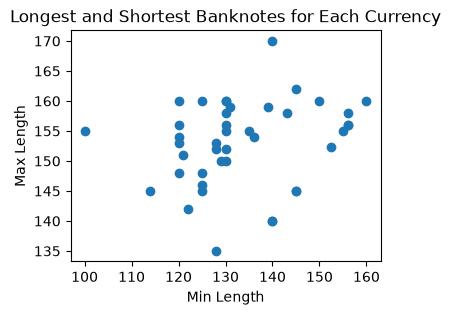

In [4]:
plt.figure(figsize=(4, 3))  
plt.scatter(length['min'], length['max'])
plt.xlabel('Min Length')
plt.ylabel('Max Length')
plt.title('Longest and Shortest Banknotes for Each Currency')
plt.show()

In [5]:
#aggregating on width 
width = df.groupby('currency').agg(max=('width', 'max'), min=('width', 'min')).reset_index()
width['diff'] = width['max'] - width['min']
width_4 = width.head(4)

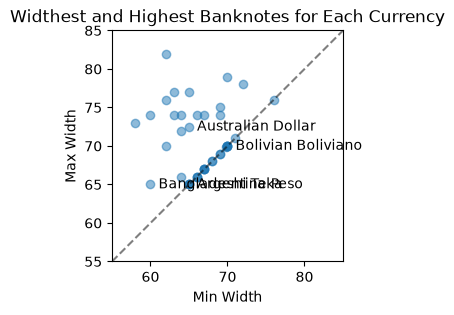

In [6]:
plt.figure(figsize=(6, 3))  
plt.scatter(width['min'], width['max'], alpha=0.5)
plt.xlabel('Min Width')
plt.ylabel('Max Width')
plt.title('Widthest and Highest Banknotes for Each Currency')

#equality line
x = [55, 85]
y = [55, 85]
plt.plot(x, y, color='black', alpha=0.5, linestyle='--')

#square up the plot
plt.xlim(55, 85)
plt.ylim(55, 85)
ax = plt.gca()
ax.set_aspect(1)

#adding labels
add_labels(width_4, 'min', 'max', 'currency')
plt.show()

 Calculate the percentage of currencies where:
 
- Only the `length` remains consistent across all denominations.
    
- Only the `width` remains consistent across all denominations.

- Both `length` and `width` vary with denominations.
    
- All denominations share identical `length` and `width` dimensions.

- Visualize these findings in a clear, engaging format.

In [52]:
#merging tables
length_width = width.merge(length, on='currency', how='left')
length_width_rows = length_width.shape[0]
length_width

,currency,max_x,min_x,diff_x,max_y,min_y,diff_y
0,Argentine Peso,65.00,65.00,0.0,155.0,155.0,0.0
1,Australian Dollar,72.50,65.00,7.5,158.0,130.0,28.0
2,Bangladeshi Taka,65.00,60.00,5.0,155.0,100.0,55.0
3,Bolivian Boliviano,70.00,70.00,0.0,140.0,140.0,0.0
4,Canadian Dollar,69.85,69.85,0.0,152.4,152.4,0.0
5,Cape Verdean Escudo,74.00,63.00,11.0,148.0,125.0,23.0
6,Central African Franc,74.00,64.00,10.0,145.0,125.0,20.0
7,Chilean Peso,70.00,70.00,0.0,148.0,120.0,28.0
8,Chinese Yuan,77.00,63.00,14.0,155.0,130.0,25.0
9,Colombian Peso,66.00,66.00,0.0,153.0,128.0,25.0


In [53]:
#filtering the rows where is legth difference equal to zero 
only_length_constant = length_width.query("diff_x > 0 &"
                                           "diff_y == 0")
only_length_constant = only_length_constant.shape[0]

In [54]:
only_length_percent = round((only_length_constant / length_width_rows) * 100, 1)
only_length_percent

0.0

In [55]:
#filtering the rows where is width diff  aqual to zero 
only_width_constant = length_width.query("diff_x == 0 &"
                                          "diff_y > 0")
only_width_constant = only_width_constant.shape[0]

In [56]:
only_width_percent = round((only_width_constant / length_width_rows) * 100, 1)
only_width_percent

33.3

In [57]:
#filtering rows where diff > 0 
both_vary = length_width.query("diff_x > 0 &"
                               "diff_y > 0")
both_vary = both_vary.shape[0]
both_vary

19

In [58]:
#percent of high_diff
both_vary_percent = round((both_vary / length_width_rows) * 100, 1)
both_vary_percent

45.2

In [59]:
#filtering rows where diff is 0
both_constant = length_width.query("diff_x == 0 &"
                               "diff_y == 0")
both_constant = both_constant.shape[0]

In [60]:
both_constant_percent = round((both_constant / length_width_rows) * 100, 1)
both_constant_percent

21.4

In [61]:
data = {'Only Length Constant':[only_length_percent],
                    'Ony Width Constant':[only_width_percent],
                    'Both Vary':[both_vary_percent],
                    'Both Identical':[both_constant_percent]
                   }

visualisation_df = pd.DataFrame(data)
visualisation_df

,Only Length Constant,Ony Width Constant,Both Vary,Both Identical
0,0.0,33.3,45.2,21.4


In [62]:
visualisation_transposed = visualisation_df.T.reset_index()
visualisation_transposed.columns = ['category', 'currency_number']

In [65]:
visualisation_transposed = visualisation_transposed.sort_values('currency_number')

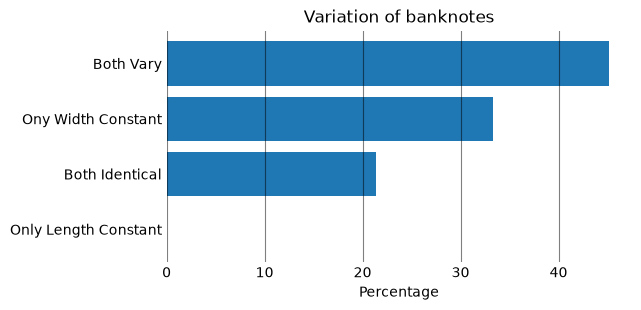

In [71]:
plt.figure(figsize=(6, 3))
plt.barh(visualisation_transposed['category'], visualisation_transposed['currency_number'])
plt.xlabel('Percentage')
plt.title('Variation of banknotes')

#swaping ticks and spines for faded grid lines
ax = plt.gca()
ax.spines[['top', 'bottom', 'left', 'right']].set_visible(False)
ax.grid(axis='x', color='black', alpha=0.5)
ax.tick_params(axis='both', length=0)
plt.show()